# Introduction
The goal of this project is to perform **face detection** by locating the **eye area** using the **Integral Image technique**.

We will:
1. Compute the Integral Image of a given face image.
2. Use it to calculate local pixel sums efficiently.
3. Convolve a kernel to detect the eye area.
4. Extract and display the detected eye region.

This notebook includes four main functions:
- `CalculateIntegral()`
- `CalculateLocalSum()`
- `DetectEye()`
- `ExtractDetectedEye()`

### Load the Image

Convert image to grayscale (since we only need intensity)



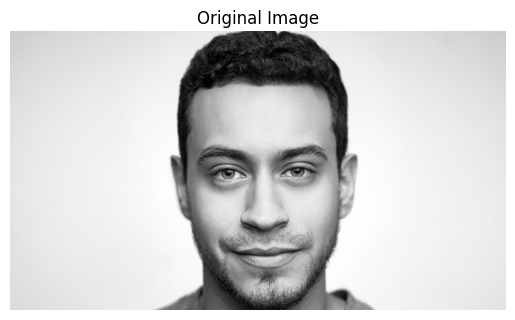

In [48]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load grayscale image
image_path = 'Image 2.jpeg'  
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) ## convert to array

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

### CalculateIntegral

**Input:**  
- 2D array representing the image

**Output:**  
- 2D array representing the integral image

**Description:**  
For each pixel (x, y):
`ii(x, y) = image(x, y) + ii(x-1, y) + ii(x, y-1) - ii(x-1, y-1)`

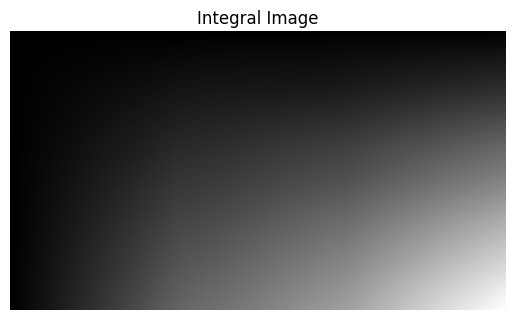

In [49]:
def CalculateIntegral(image):
    h, w = image.shape
    ii = np.zeros((h, w), dtype=np.float64)

    for y in range(h):
        for x in range(w):
            ii[y, x] = image[y, x]
            if x > 0:
                ii[y, x] += ii[y, x-1]
            if y > 0:
                ii[y, x] += ii[y-1, x]
            if x > 0 and y > 0:
                ii[y, x] -= ii[y-1, x-1]
    return ii

# Test it
integral_img = CalculateIntegral(image)
plt.imshow(integral_img, cmap='gray')
plt.title('Integral Image')
plt.axis('off')
plt.show()

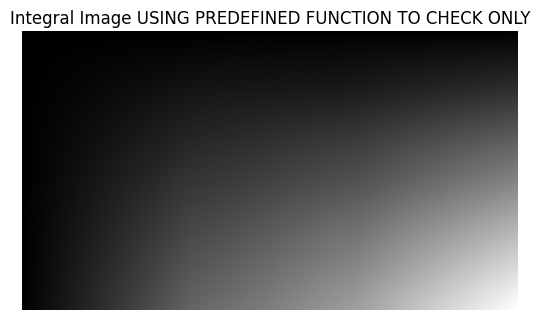

In [50]:
import cv2
integral_cv = cv2.integral(image)
integral_vis = integral_cv[1:, 1:]

plt.imshow(integral_vis, cmap='gray')
plt.title('Integral Image USING PREDEFINED FUNCTION TO CHECK ONLY')
plt.axis('off')
plt.show()


### CalculateLocalSum

**Input:**  
- An integral image (2D array)
- Two pairs of coordinates: (x0, y0) (upper left), (x1, y1) (lower right)

**Output:**  
- The local sum for the rectangular area defined by the pair of points

**Description:**  
This function calculates the local sum for any rectangular area using the integral image. It should not contain any loops.

In [51]:
def CalculateLocalSum(ii, p0, p1):
    x0, y0 = p0
    x1, y1 = p1

    total = ii[y1, x1]
    if x0 > 0:
        total -= ii[y1, x0 - 1]
    if y0 > 0:
        total -= ii[y0 - 1, x1]
    if x0 > 0 and y0 > 0:
        total += ii[y0 - 1, x0 - 1]
    return total

# Example test
sum_test = CalculateLocalSum(integral_img, (10,10), (50,50))
print(sum_test)

354879.0


In [52]:
np.sum(image[10:51, 10:51])
#yes

np.uint64(354879)

### Define the Kernel (Eye Detector)

The kernel is made of several rectangles, each with a specific weight.

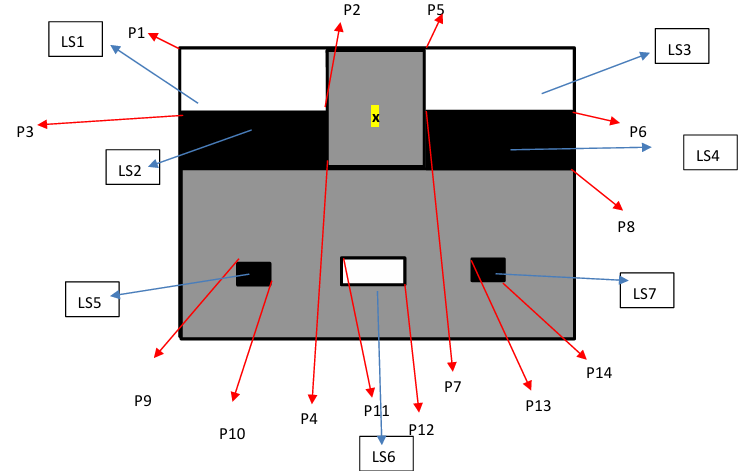
| Rectangle | Relative Position           | Weight | Color  |
|-----------|-----------------------------|--------|--------|
| LS1       | Upper-left                  | +1     | White  |
| LS2       | Upper-middle (between eyes) | –1     | Black  |
| LS3       | Upper-right                 | +1     | White  |
| LS4       | Lower-left                  | –1     | Black  |
| LS5       | Lower-middle                | –1     | Black  |
| LS6       | Lower-center (between eyes) | +2     | White  |
| LS7       | Lower-right                 | –1     | Black  |


*Assign regions and boundaries based on P1–P14 as shown in the assignment image. 
Weights strictly follow the assignment instructions for color: white = +1, black = –1, gray = 0 (neglected).*


###  Given Position i and j in the integral image Calculate the 14 points of the kernel

In [53]:
def _CalculateKernelPoints(center_j, center_i, n, m):
    """
    Calculate the 14 points of the kernel relative to center position
    
    Input:
        center_j: x-coordinate of center (column)
        center_i: y-coordinate of center (row)
        n: kernel width
        m: kernel height parameter (0.15 * n)
    
    Output:
        Dictionary containing all 14 points (p1 to p14)
    """
    points = {}
    
    points['p1'] = (center_j - int(0.5*n), center_i - int(0.5*m))
    points['p2'] = (center_j - int(0.05*n), center_i)
    points['p3'] = (center_j - int(0.5*n), center_i)
    points['p4'] = (center_j - int(0.05*n), center_i + int(0.5*m))
    points['p5'] = (center_j + int(0.05*n), center_i - int(0.5*m))
    points['p6'] = (center_j + int(0.5*n), center_i)
    points['p7'] = (center_j + int(0.05*n), center_i)
    points['p8'] = (center_j + int(0.5*n), center_i + int(0.5*m))
    points['p9'] = (center_j - int(0.325*n), center_i + int(0.833*m))
    points['p10'] = (center_j - int(0.225*n), center_i + 2*m)
    points['p11'] = (center_j - int(0.1*n), center_i + int(0.833*m))
    points['p12'] = (center_j + int(0.1*n), center_i + 2*m)
    points['p13'] = (center_j + int(0.225*n), center_i + int(0.833*m))
    points['p14'] = (center_j + int(0.325*n), center_i + 2*m)
    
    return points

### Calculate the Score of given kernal position:

- Compute local sums for each rectangle using the integral image.
- Multiply each by its weight.
- return result`.

In [54]:
def _CalculateKernelScore(integral_image, points):
    """
    Calculate kernel score - IMPLEMENTATION IS CORRECT
    """
    p1 = points['p1']   # (-0.5n, -0.5m)
    p2 = points['p2']   # (-0.05n, 0)
    p3 = points['p3']   # (-0.5n, 0)
    p4 = points['p4']   # (-0.05n, +0.5m)
    p5 = points['p5']   # (+0.05n, -0.5m)
    p6 = points['p6']   # (+0.5n, 0)
    p7 = points['p7']   # (+0.05n, 0)
    p8 = points['p8']   # (+0.5n, +0.5m)
    p9 = points['p9']   # (-0.325n, +0.833m)
    p10 = points['p10'] # (-0.225n, +2m)
    p11 = points['p11'] # (-0.1n, +0.833m)
    p12 = points['p12'] # (+0.1n, +2m)
    p13 = points['p13'] # (+0.225n, +0.833m)
    p14 = points['p14'] # (+0.325n, +2m)
    
    # LS1: Rectangle from P1 to (P2.x, P4.y)
    ls1 = CalculateLocalSum(integral_image, p1, (p2[0]-1, p4[1]-1))
    
    # LS2: Rectangle from P3 to P4
    ls2 = CalculateLocalSum(integral_image, p3, (p4[0]-1, p4[1]-1))
    
    # LS3: Rectangle from P5 to (P6.x, P8.y)
    ls3 = CalculateLocalSum(integral_image, p5, (p6[0]-1, p8[1]-1))
    
    # LS4: Rectangle from P7 to P8
    ls4 = CalculateLocalSum(integral_image, p7, (p8[0]-1, p8[1]-1))
    
    # LS5: Small black rectangle (bottom-left)
    ls5 = CalculateLocalSum(integral_image, p9, (p10[0]-1, p10[1]-1))
    
    # LS6: Small white rectangle (bottom-middle)
    ls6 = CalculateLocalSum(integral_image, p11, (p12[0]-1, p12[1]-1))
    
    # LS7: Small black rectangle (bottom-right)
    ls7 = CalculateLocalSum(integral_image, p13, (p14[0]-1, p14[1]-1))
    
    score = ls1 - ls2 + ls3 - ls4 - ls5 + ls6 - ls7
    
    return score

### DetectEye

**Input:**  
- The integral image (2D array)
- Kernel width (n)

**Output:**  
- Coordinates (i, j) representing the position of the maximum score from kernel convolution

**Description:**  
Finds the region with the highest score corresponding to the eye area, by convolving the kernel across the face image. Kernel height is calculated as m = 0.15n. The kernel should use the structure provided in the assignment.

In [55]:
def DetectEye(integral_image, kernel_width):
    """
    Detect eye area by sliding kernel across image
    
    Input:
        integral_image: the integral image
        kernel_width: width of kernel (n)
        CalculateLocalSum: function reference to calculate local sum
    
    Output:
        max_position: (i, j) coordinates of maximum score
    """
    n = kernel_width
    m = int(0.15 * n)  # kernel height
    
    rows, cols = integral_image.shape
    max_score = -np.inf
    max_position = (0, 0)
    
    # Slide kernel across image
    for i in range(rows - 2*m):
        for j in range(int(n/2), cols - int(n/2)):
            
            # Step 1: Calculate the 14 kernel points at this position
            points = _CalculateKernelPoints(j, i, n, m)
            
            # Check boundaries
            p1 = points['p1']
            p10 = points['p10']
            p14 = points['p14']
            
            if (p1[0] < 0 or p1[1] < 0 or p10[0] < 0 or p10[1] >= rows or 
                p14[0] >= cols or p14[1] >= rows):
                continue
            
            # Step 2: Calculate kernel score at this position
            score = _CalculateKernelScore(integral_image, points)
            
            # Step 3: Track maximum score
            if score > max_score:
                max_score = score
                max_position = (i, j)
    
    return max_position

### for test only

In [56]:
eye_position = DetectEye(integral_img, kernel_width=330)
print(f"Eye detected at: {eye_position}")

Eye detected at: (24, 754)


### ExtractDetectedEye

**Input:**  
- The original image (2D array)
- Position of detected maximum score (i, j)
- Kernel width (n)

**Output:**  
- A 2D array representing the image area containing the detected eye region

**Description:**  
Draws around the detected maximum position using the kernel size, retrieves and returns the pixel region corresponding to the eyes.